In [1]:
import numpy as np 

from scipy.constants import c as c0
from scipy.interpolate import CubicSpline

In [3]:
import sys
from pathlib import Path

# Adding to path
#PROJECT_ROOT = Path("/home/lsito/mast") 
PROJECT_ROOT = Path("c:/Users/Leonardo/Desktop/Mast/mast") # On my Windows Laptop

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.gui.meas_config_dialog import MeasurementConfigDialog
from src.data_models.meas_config import MeasurementConfig

from src.gui.structure_config_dialog import RFStructureLoaderDialog
from src.data_models.rf_structure import RFStructureParams

from src.core.config_parser import DataMixin

In [4]:
# In case you need to check the current working directory
from pathlib import Path
Path.cwd()

WindowsPath('c:/Users/Leonardo/Desktop/Mast/mast/notebook')

In [6]:
# Parameter definition test

RF_params = RFStructureParams.from_json("../data/2021_03_18_-_TD31_Nx-raw_data/00-Config_Files/TD31_R1_CC.json")
Meas_params = MeasurementConfig()

print((RF_params.vg_))

[9008763.36289999 8756937.69818    8508709.542956   8264078.897228
 8023045.760996   7785610.13426    7551772.01702    7321531.409276
 7094888.311028   6871842.722276   6652394.64302    6436544.07326
 6224291.012996   6015635.462228   5810577.420956   5609116.88918
 5411253.8669     5216988.354116   5026320.350828   4839249.857036
 4655776.87274    4475901.39794    4299623.432636   4126942.976828
 3957860.030516   3792374.5937     3630486.66638    3472196.248556
 3317503.340228   3166407.941396   3018910.05206    2875009.67222
 2734706.801876  ]


In [7]:
# Target Frequency (Should be the frequency of the source) in Hz --> This is computed from the measurement config as target frequency to tune
f1 = 11.9942e9 
f1 = Meas_params.target_frequency_mhz * 1e6

# Resonant frequency of the bead-pull (written in the name of the file) --> Should be the frequency of the cavity
f0 = 11.993e9 
f = f0 # Just supoport variable

# Normalized frequency detuning for small detunings
    # Note: this is Eq. (3) however, it looks like the sign is opposite.
DeltaF = -2 * (f1-f0) / f0

# Group velocity interpolation
    # This is a list of group velocities for each cell, given in the json config file, apparently at the beginning of the cell (0, 1, 2, ..., noc-1)
    # we need vg at the middle of the cell (0.5, 1.5, ..., noc-0.5) for the calculation of Qe and beta, so we need to interpolate it with a cubic spline
    # 0.5   1   1.5   2   2.5   3   ...
    #  |    *    |    *    |    *
    #      vg1       vg2       vg3

vg = RF_params.vg_

    # Number of cells, given in the json config file
noc = RF_params.noc 

# Issue here
x = np.arange(1, noc+1)          # 1, 2, ..., noc # This is Matlab indexing
x_interp = np.arange(0.5, noc + 1 + 0.5) # 0.5, 1.5, ..., noc + 0.5

spline = CubicSpline(x, vg, bc_type="not-a-knot", extrapolate=True, axis=0)
vg_ = spline(x_interp)

# External Q approximated from Eq. (5)

    # This is the phase advance (NOT per cell), given in the json config file
phi0 = RF_params.phi0 
Q0 = RF_params.Q0_
Qe = c0 * phi0 / vg_

# Coupling coefficient beta of each cell from Wangler Chapt.5.5
# Qe:      Qe1      Qe2      Qe3      Qe4      Qe5
#           |        |        |        |        |
# 
# beta:   beta1    beta2    beta3    beta4
#         uses     uses     uses     uses
#         Qe1,Qe2  Qe2,Qe3  Qe3,Qe4  Qe4,Qe5
# Notice that here the cell is treated as a single input system; hence the power flowing out of the second 
# port is accounted for as power lost
# Hence Beta(i) = P_ext(1)/(P0(i)+P_ext(i+1)) = 1/Qe(i) / (1/Q0(i) + 1/Qe(i+1))

Q0 = np.array(Q0)
Qe_i = np.array(Qe[:-1])
Qe_ip1 = np.array(Qe[1:])

beta = (1/Qe_i) / (1/Q0 + 1/Qe_ip1)

# Reflection from the input port (from Eq. (1) with Q0 = Qe)

gamma_num = (beta-1)*(beta+1) - Qe_i**2 * DeltaF**2 - 1j*2*beta*Qe_i*DeltaF
gamma_den = (beta+1)**2 + Qe_i**2 * DeltaF**2
gamma = gamma_num / gamma_den

In [8]:
# Cumulative attenuation computation from Eq. (19) but already as an exponential term
v_particles = RF_params.v_particles

alpha = (v_particles * phi0) / (Q0 * vg)

att = np.ones(noc+1)

att[0] = 1.0
att[1:noc] = np.exp(-np.cumsum(alpha[:-1]))
att[-1] = att[-2] * np.exp(-alpha[-1])

## Up to now this was bbpare up to line 213 where bp_eval_routine gets called

What was up should still be in RF structure datamodel (as properties maybe)

Should be a routine to read and evaluate beadpull files (this should be in bead_config)

In [9]:
# Loading csv file (in this case saved locally, but in the future it should be saved direclty from VNA)

from src.io_utils.csv import read_csv

filename = "/home/lsito/mast/data/2021_03_18_-_TD31_Nx-raw_data/01-Before_Tuning/BP_11989.24_19.1deg.csv"

# Just raising an error in case the file is not csv
ext = Path(filename).suffix.lower()
if ext != ".csv":
    raise NotImplementedError(f"Only .csv is supported here, got {ext}")

f, scc11, scc21, scc12, scc22 = read_csv(filename)

In [10]:
## Signals are already balanced by src.io_utils.csv read_csv method

## If the structure was measured with Ports (1, 3) as input, then we take scc11
## If the structure was measured with Ports (2, 4) as input, then we take scc22
from matplotlib.table import Cell


use_S_output_for_BP = False

if not use_S_output_for_BP:
    # Input-side bead-pull signal
    aorg = scc11
else:
    # Output-side bead-pull signal
    aorg = scc22
aorg = np.asarray(aorg, dtype=np.complex128)

## Check if the units are not in mU
if np.max(np.abs(aorg)) > 1:
    aorg = 1e-3 * aorg

## Did we select inverse measurement option?
    # Input  -----------------> Output
    # Cell 1 Cell 2 ... Cell 33

    # Output -----------------> Input
    # Cell 33 Cell 32 ... Cell 1

RF_params.option_inverse = False

if RF_params.option_inverse:    
    aorg = aorg[::-1]

# Finally storing --> This should be in the data class for the beadpull measurement, but for now we just store it in a variable
sorg = aorg.copy()

In [11]:
# Zero Line Extraction
# Zero Line Check
# Using the first and last 30 samples we need to find and subtract a proper baseline.
# There are two very simple approaches with a 0-order model or a linear model

n_zero = 30 # Number of samples to use for zero-line estimation at the beginning and end of the signal
n = len(aorg)

# Just checking if we actually have enough points
if n < 2 * n_zero:
    raise ValueError(
        f"aorg has only {n} points, but zero-line extraction needs "
        f"at least {2 * n_zero} points."
    )

# First and last 30 samples
x_fit = np.concatenate([
    np.arange(n_zero),
    np.arange(n - n_zero, n),
])

y_fit = np.concatenate([
    aorg[:n_zero],
    aorg[-n_zero:],
])

# Global zero-line estimate (needed later)
a_zero_l = np.mean(aorg[:n_zero]) # This is just a value given the average of the point in the left interval
gamma0 = a_zero_l

# Constant zero-line estimate
a_zero_lr = np.mean(y_fit) * np.ones_like(aorg) # This is a constant vector given the mean of the left and right intervals

# Linear zero-line fit, 
# Fit real and imaginary parts separately for clarity.
coef_re = np.polyfit(x_fit, y_fit.real, deg=1)
coef_im = np.polyfit(x_fit, y_fit.imag, deg=1)

x = np.arange(n)

a_zero = (
    np.polyval(coef_re, x)
    + 1j * np.polyval(coef_im, x)
)

# Baseline-subtracted bead-pull signal
a = aorg - a_zero

# Need to store in the bead-pull measurement data class, but for now we just store it in a variable

In [12]:
# Check of zero line 

max_zero_line_deviation = 1e-3 # Threshold when checking
n_zero = 30 # Number of samples to use for zero-line check at the beginning and end of the signal

n = len(a)

# First and last 30 samples of the baseline-subtracted signal
zero_region = np.concatenate([
    a[:n_zero],
    a[-n_zero:],
])

# Robust estimate of bead-pull signal amplitude:
# use the 10%-largest value instead of the absolute maximum,
# to avoid being dominated by one noisy spike.
abs_signal_sorted = np.sort(np.abs(a))[::-1]

idx_10_percent = int(np.floor(len(abs_signal_sorted) * 0.1))
reference_amplitude = abs_signal_sorted[idx_10_percent]

# Residual zero-line signal relative to the bead-pull signal amplitude
relative_zero_residual = zero_region / reference_amplitude

relative_zero_sorted = np.sort(np.abs(relative_zero_residual))[::-1]

# MATLAB uses the 3rd largest residual
third_largest_residual = relative_zero_sorted[2]

if third_largest_residual > max_zero_line_deviation:
    print(
        f'!!! Problem in 0-line fitting, filename="{filename}" !!!'
    )
    print("Details:")
    print(f"  N_BP_0_points_begining_end = [{n_zero}, {n_zero}]")
    print(
        f"  3rd largest relative residual = {third_largest_residual:.6f} "
        f"> Max_zero_line_deviation = {max_zero_line_deviation:.6f}"
    )

In [13]:
# Plotting if needed: this correspond to the matlab script "zero_line_check.m"

import numpy as np
import matplotlib.pyplot as plt

def zero_line_check(aorg, a_zero, title="", verbose=0):
    """
    Python equivalent of MATLAB zero_line_check.m.

    Parameters
    ----------
    aorg : array-like of complex
        Original complex bead-pull signal.

    a_zero : array-like of complex
        Fitted zero-line / baseline.

    title : str
        Plot title.

    verbose : int
        If >= 10, print debug message.
    """

    if verbose >= 10:
        print('\n  This is the "zero_line_check" function')

    aorg = np.asarray(aorg, dtype=np.complex128)
    a_zero = np.asarray(a_zero, dtype=np.complex128)

    z = np.arange(len(aorg))

    fig = plt.figure(figsize=(12, 6))


    # Top-left: real and imaginary parts

    ax1 = fig.add_subplot(2, 2, 1)

    ax1.plot(z, aorg.real, label="Re")
    ax1.plot(z, aorg.imag, label="Im")
    ax1.plot(z, a_zero.real, "--", label="Re zero-line")
    ax1.plot(z, a_zero.imag, "--", label="Im zero-line")

    ax1.set_xlim(0, len(aorg) - 1)
    ax1.set_xlabel("z")
    ax1.set_ylabel("Re(S11) and Im(S11)")
    ax1.set_title(title, loc="left")
    ax1.legend()

    ax1.grid(True, linestyle="--", alpha=0.8,)

    # Bottom-left: absolute values

    ax2 = fig.add_subplot(2, 2, 3)

    ax2.plot(z, np.abs(aorg), label="abs(aorg)")
    ax2.plot(z, np.abs(a_zero), "--", label="abs(a_zero)")

    ax2.set_xlim(0, len(aorg) - 1)
    ax2.set_xlabel("z")
    ax2.set_ylabel("Abs(S11)")
    ax2.legend()

    ax2.grid(True, linestyle="--", alpha=0.8,)


    # Right: complex plane plot
    ax3 = fig.add_subplot(1, 2, 2)

    ax3.plot(aorg.real, aorg.imag, label="aorg")
    ax3.plot(a_zero.real, a_zero.imag, label="a_zero")

    z0plot = np.mean(a_zero)
    max_r = np.max(np.abs(aorg - z0plot))

    ax3.set_xlim(z0plot.real - max_r, z0plot.real + max_r)
    ax3.set_ylim(z0plot.imag - max_r, z0plot.imag + max_r)
    ax3.set_aspect("equal", adjustable="box")

    ax3.set_xlabel("Re(S11)")
    ax3.set_ylabel("Im(S11)")
    ax3.set_title(title, loc="left")
    ax3.legend()

    ax3.grid(True, linestyle="--", alpha=0.8,)


    fig.tight_layout()
    plt.show()

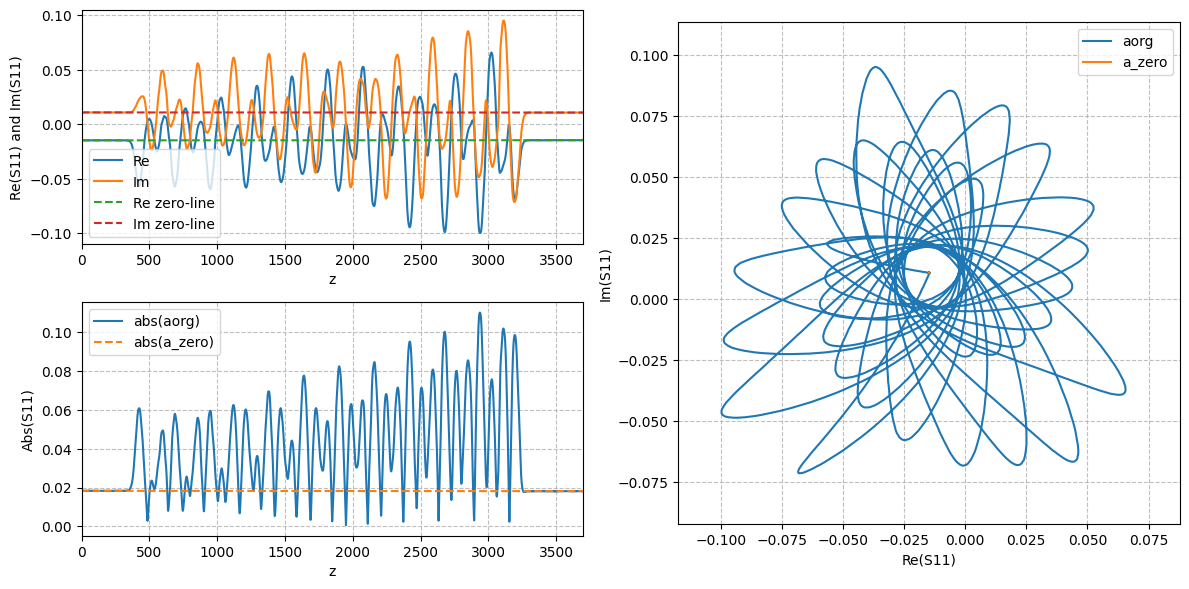

In [14]:
zero_line_check(
    aorg=aorg,
    a_zero=a_zero,
)

In [15]:
## Now from "bp_eval_routine.m" starting at line 176 we need to find the peaks...

from scipy.ndimage import uniform_filter1d
from scipy.signal import find_peaks

# Working on a copy of the signal a (so after zero line)
atp = a.copy()

# All values below 15% of the signal maximum amplitude are water-levelled
threshold = 0.15 * np.max(np.abs(atp))
atp[np.abs(atp) < threshold] = 0

# Smoothing
abs_atp_smooth = uniform_filter1d(np.abs(atp), size=5, mode="nearest")

# Find peaks and peaks' locations
locpk, _ = find_peaks(abs_atp_smooth)
pks = abs_atp_smooth[locpk]

# Reference complex values at the detected peaks
dref = a[locpk]

# Detect double peaks allowing a tollerance of at most 5 deg
phase_tolerance = 5 * np.pi / 180

# Phase difference between two following peaks computed like:
# dref(0)   dref(1)    dref(2)     ...    dref(end-1)    dref(end)
#              /          /                                  /
#           dref(0)    dref(1)    dref(2)    ...         dref(end-1)    dref(end)    

phase_diff = np.abs(np.angle(dref[1:] / dref[:-1]))
idx_double = np.where(phase_diff < phase_tolerance)[0]

# Keep copies before removing double peaks, useful for diagnostics
locpk_raw = locpk.copy()
dref_raw = dref.copy()
pks_raw = pks.copy()

# Remove double peaks
#
# For each pair of neighboring peaks with almost the same phase,
# keep the one with the larger amplitude.

n_removed = 0

for idx in idx_double:
    # If I have removed something all the indexes after have to be shifted
    i = idx - n_removed

    if i < 0 or i + 1 >= len(dref):
        continue

    if np.abs(dref[i]) >= np.abs(dref[i + 1]):
        # Keep first peak, remove second
        locpk = np.delete(locpk, i + 1)
        dref = np.delete(dref, i + 1)
    else:
        # Remove first peak, keep second
        locpk = np.delete(locpk, i)
        dref = np.delete(dref, i)

    n_removed += 1

# Update peak amplitudes after cleaning
pks = abs_atp_smooth[locpk]

/tmp/ipykernel_2094/2866031705.py:33: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  sc = ax.scatter(


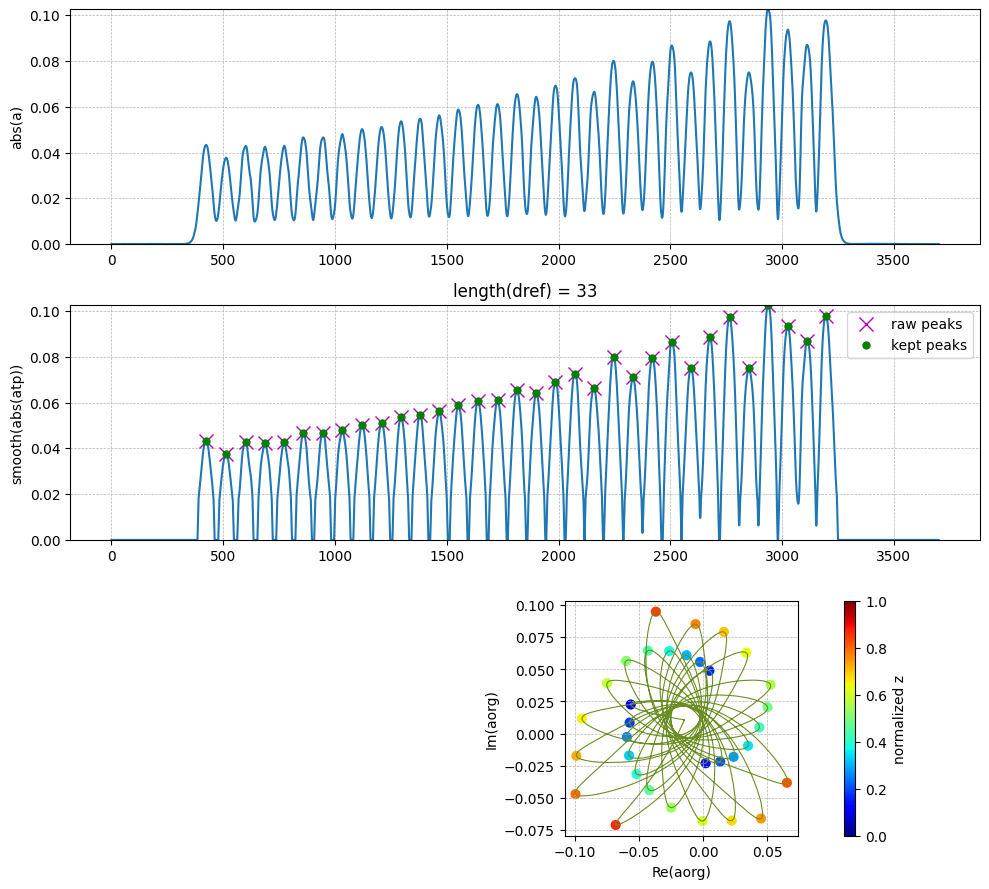

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9))

py = np.abs(a)

axes[0].plot(py)
axes[0].set_ylabel("abs(a)")
axes[0].set_ylim(0, np.max(py))
axes[0].grid(True, linestyle="--", linewidth=0.5, color="0.7")

py = abs_atp_smooth

axes[1].plot(py)
axes[1].plot(locpk_raw, py[locpk_raw], "mx", markersize=10, label="raw peaks")
axes[1].plot(locpk, py[locpk], "go", markersize=5, label="kept peaks")

axes[1].set_ylabel("smooth(abs(atp))")
axes[1].set_ylim(0, np.max(py))
axes[1].set_title(f"length(dref) = {len(dref)}")
axes[1].legend()
axes[1].grid(True, linestyle="--", linewidth=0.5, color="0.7")

ax = axes[2]

ax.plot(
    aorg.real,
    aorg.imag,
    color="olivedrab",
    linewidth=0.8,
)

peak_color = locpk / (len(aorg) - 1)

sc = ax.scatter(
    aorg.real[locpk],
    aorg.imag[locpk],
    c=peak_color,
    cmap="jet",
    vmin=0,
    vmax=1,
    s=35,
    facecolors="none",
    linewidths=1.4,
)

ax.set_xlabel("Re(aorg)")
ax.set_ylabel("Im(aorg)")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, linestyle="--", linewidth=0.5, color="0.7")

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("normalized z")

plt.tight_layout()
plt.show()

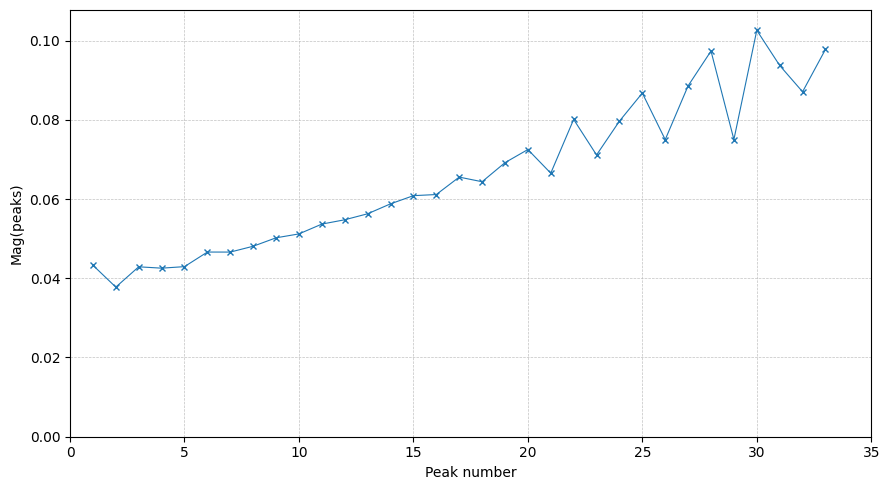

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    np.arange(1, len(dref) + 1),
    np.abs(dref),
    "x-",
    color="tab:blue",
    linewidth=0.8,
    markersize=5,
)

ax.set_xlabel("Peak number")
ax.set_ylabel("Mag(peaks)")
ax.set_xlim(0, len(dref) + 2)
ax.set_ylim(0, 1.05 * np.max(np.abs(dref)))

ax.grid(True, linestyle="--", linewidth=0.5, color="0.7", alpha=0.8)

plt.tight_layout()
plt.show()

In [ ]:
## Final computations:

# Does the number of electromagnetic peaks determined match with the number of cells present by design?

noc = RF_params.noc # Number of cells
nop = len(dref) # Number of peaks

if nop != noc:
    print()
    print("Problem: the number of EM-field peaks is not right.")
    print(f"Detected peaks: {nop}")
    print(f"Expected peaks: {noc}")
    print()

    peak_magnitudes = np.abs(dref)

    meanpeaks = np.mean(peak_magnitudes)
    stdpeaks = np.std(peak_magnitudes, ddof=0)

    meanpeakdistance = np.mean(np.diff(locpk))

    # Sort peaks by how much their magnitude deviates from the mean.
    # Largest deviations come first.
    deviation = np.abs(peak_magnitudes - meanpeaks)
    ns = np.argsort(deviation)[::-1]

    if nop > noc:
        n_extra = nop - noc

        # Python indices, 0-based
        bad_peaks_idx = np.sort(ns[:n_extra])

        # Human-readable peak numbers, MATLAB-style 1-based
        bad_peaks_number = bad_peaks_idx + 1

        print("Suggested false peaks to remove:")
        print(bad_peaks_number)

    else:
        bad_peaks_idx = np.array([], dtype=int)
        bad_peaks_number = np.array([], dtype=int)

        print("Too few peaks were detected.")
        print("In this case you probably need to tune the peak detection, not remove peaks.")

# TODO We need some tool for the proper detection of peaks in case the method implemented fails
"""
remove_peaks = []  # fill manually if needed, e.g. [4, 17]

if len(remove_peaks) > 0:
    # Convert from human/MATLAB-style 1-based peak numbers
    # to Python 0-based indices.
    remove_idx = np.array(remove_peaks, dtype=int) - 1

    # Remove from the end so earlier indices stay valid.
    remove_idx = np.sort(remove_idx)[::-1]

    for idx in remove_idx:
        locpk = np.delete(locpk, idx)
        dref = np.delete(dref, idx)

noc = len(dref)
"""


'\nremove_peaks = []  # fill manually if needed, e.g. [4, 17]\n\nif len(remove_peaks) > 0:\n    # Convert from human/MATLAB-style 1-based peak numbers\n    # to Python 0-based indices.\n    remove_idx = np.array(remove_peaks, dtype=int) - 1\n\n    # Remove from the end so earlier indices stay valid.\n    remove_idx = np.sort(remove_idx)[::-1]\n\n    for idx in remove_idx:\n        locpk = np.delete(locpk, idx)\n        dref = np.delete(dref, idx)\n\nnoc = len(dref)\n'

In [19]:
# Phase extraction
phi = RF_params.phi

# Phase unwrap
phase = np.unwrap(np.angle(a))
phase_peaks = phase[locpk]

# Correct phase branch errors

dphase_peaks = -np.diff(phase_peaks)

Dpp = (dphase_peaks - 2 * phi) / (2 * np.pi)

ffx = np.where(np.abs(Dpp) >= 0.5)[0]

if len(ffx) > 0:
    for idx in ffx:
        phase_shift = np.round(Dpp[idx]) * 2 * np.pi

        # Correct this phase jump
        dphase_peaks[idx] = dphase_peaks[idx] - phase_shift

        # Shift all following peak phases.
        phase_peaks[idx + 1:] += phase_shift

In [20]:
dphi_c = -np.diff(phase_peaks)
Dpp_c = (dphi_c - 2 * phi) / (2 * np.pi)

ff = np.where(np.abs(Dpp_c) >= 0.5)[0]

if len(ff) > 0:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 4))
    plt.plot(phase, "x-", label="unwrapped phase")
    plt.plot(locpk, phase_peaks, "ro-", label="phase at peaks")
    plt.grid(True, linestyle="--", linewidth=0.5, color="0.7")
    plt.legend()
    plt.title("Possible remaining phase branch problem")
    plt.show()

In [21]:
# Getting proper phase-advance and field to plot

phase_peaks = phase_peaks - np.round(phase_peaks[0] / (2 * np.pi)) * 2 * np.pi

Ebp = np.sqrt(np.abs(dref)) * np.exp(1j * phase_peaks / 2)

phiadv = -np.diff(phase_peaks / 2) / np.pi * 180

phimean = np.mean(phiadv[1:-1])
phisig = 0

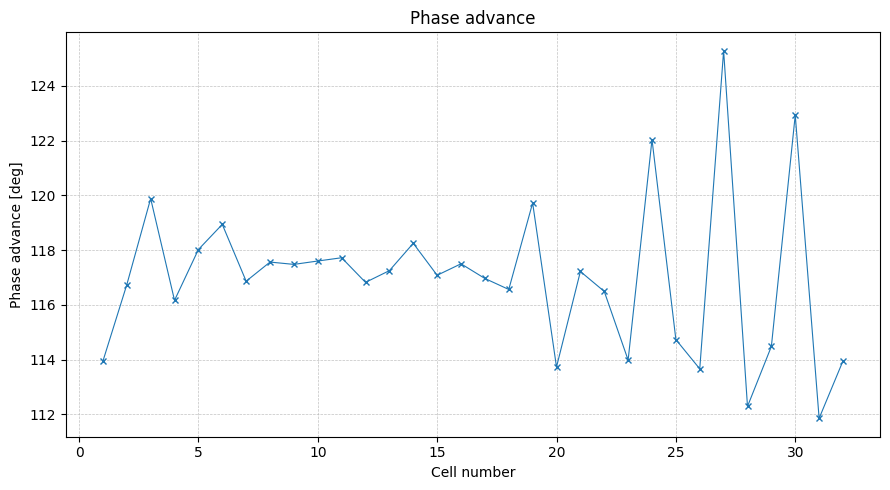

In [22]:
# Plotting Phase Advance
cell_number = np.arange(1, len(phiadv) + 1)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(cell_number, phiadv, "x-", linewidth=0.8, markersize=5)

ax.set_xlabel("Cell number")
ax.set_ylabel("Phase advance [deg]")
ax.set_title("Phase advance")

ax.grid(True, linestyle="--", linewidth=0.5, color="0.7", alpha=0.8)

plt.tight_layout()
plt.show()

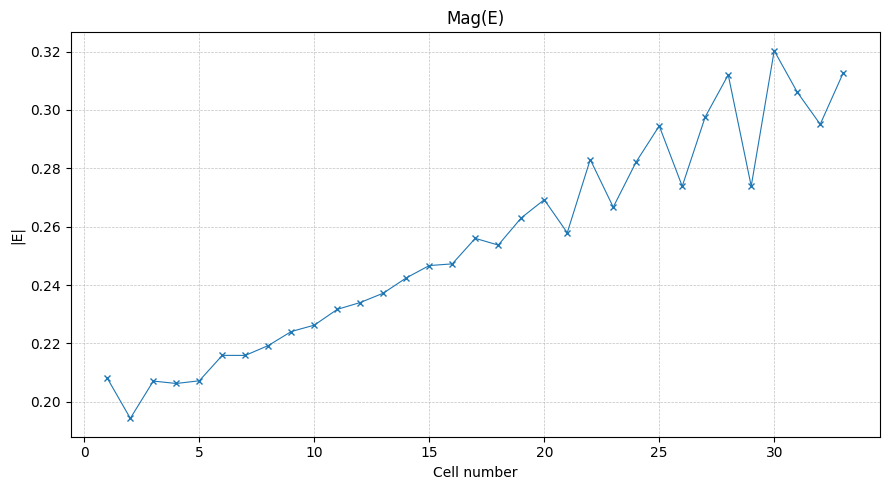

In [23]:
# Peak Electric field magnitude:

cell_number = np.arange(1, len(Ebp) + 1)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(cell_number, np.abs(Ebp), "x-", linewidth=0.8, markersize=5)

ax.set_xlabel("Cell number")
ax.set_ylabel("|E|")
ax.set_title("Mag(E)")

ax.grid(True, linestyle="--", linewidth=0.5, color="0.7", alpha=0.8)

plt.tight_layout()
plt.show()

In [ ]:
# Now finally, the last part of bbparse.m starting at line 219
# forward/backward wave amplitudes, then estimates local reflection / detuning quantities cell by cell.

# Constants were already defined previously given by the config file of the structure
vg = np.asarray(RF_params.vg)
vg_ = RF_params.vg_
phi = np.asarray(RF_params.phi)
phi0 = RF_params.phi0
fref = RF_params.fref
v_particles = RF_params.v_particles
noc = RF_params.noc

In [37]:
# Physical Cell Length (assuming phi0 as phase advance)
d = phi0 * v_particles / fref / (2 * np.pi)

# R/Q is in Ohm/m (Linac Ohm per unit accelerating length)
# Remember, variables of rf_structure with an _ are including coupling cells
rovq = np.asarray(RF_params.rovq_) * d

# Normalized field?
squ = Ebp / np.sqrt(rovq)

In [38]:
# Determining forward and backward wave (from Eq. 8 to 15)

I = squ # Field in the structure superposition of forward and backward waves

A = np.zeros(noc + 1, dtype=np.complex128) # Forward wave
B = np.zeros(noc + 1, dtype=np.complex128) # Backward wave

# input                                           output
#   |                                               |
#   v                                               v

#   A[0] -> cell 1 -> A[1] -> cell 2 -> ... -> A[noc]
#   B[0] <- cell 1 <- B[1] <- cell 2 <- ... <- B[noc]

# Implementing Eq. 10
# A[1:-1]=             x        x             x
# A      =    A[0]    A[1]    A[2] ... ... A[N-2]    A[N-1]
# B      =    B[0]    B[1]    B[2] ... ... B[N-2]    B[N-1]
# I      =    I[0]    I[1]    I[2] ... ... I[N-2]    I[N-1]
# I[:-1] =      x      x        x             x
# I[1:]  =             x        x             x        x

A[1:-1] = (I[:-1] - I[1:] * np.exp(-1j * phi)) / (2j * np.sin(phi))

B[1:-1] = (I[:-1] - I[1:] * np.exp(+1j * phi)) / (-2j * np.sin(phi))

# Output cell
A[-1] = (A[-2] * (1 - abs(B[-2] / A[-2])) * np.exp(1j * phi[-1])) 
# A[-1] = (A[-2] + B[-2]) / (2*1j*np.sin(phi[-1])+ np.exp(-1j * phi[-1]))
B[-1] = 0

# Input cell from Eq. 13
A[0] = A[1] * np.exp(1j * phi[0])
# From Eq. 13 B[0] = A[0]*S11*exp(-2jphi0), with phi0 the phase offset of the input waveguide.
# This can be computed from Eq. 14: exp(-2jphi0) = -j * |dref[0]|/dref[0]
B[0] = A[0] * gamma0 * (-1j * np.abs(dref[0]))/(dref[0])

In [45]:
# Computation of local reflection coefficients

# Using a mean phase value for filling the array in a first pass (it will be overwritten)
mean_phi_inner = np.mean(phi[1:-1])

# From Eq. 11
s11local = (B[:-1] - B[1:] * np.exp(-1j * mean_phi_inner)) / A[:-1]
ds11local = -(B[:-1] - B[1:] * np.exp(-1j * mean_phi_inner)) / A[:-1]

# Now truly Eq. 11 with 2<=n<=N-1; Notice, we are still missing the correct values in input and output
s11local[1:] = (B[1:-1] - B[2:] * np.exp(-1j * phi)) / A[1:-1]
ds11local[1:] = -(B[1:-1] - B[2:] * np.exp(-1j * phi)) / A[1:-1]

# Including losses
att = np.asarray(att)
ds11global = ds11local * att[:len(ds11local)]

# Local correction for frequency variation due to temperature (bpparse.m line 273)
    # Store a copy
s11local_org = np.array(s11local, copy=True)
    
    # Compute temperature correction based on frequency shifts
ds11local_dtemp = 1j * (f0-f1)/fref * v_particles * phi0 / vg_ # Notice this should be vg_ including the in and out cells but not the further interpolation done in the calculations
    # Compute again s11 local adding this correction
s11local = s11local + ds11local_dtemp

# Global correction for s11
ds11 = (np.imag(ds11global) + (f1 - f0)  / fref * v_particles * phi0 / vg_ * att[:len(ds11local)])

# Frequency shift to apply to each cell
df2tune = (np.imag(ds11local) / (v_particles * phi0 / vg_)) * fref + (f1-f0)

# Output matching correction assuming two cells are used
idx112 = np.arange(5, -1, -1)

ref_end_comp = (B[-8:-2] / A[-8:-2] / (att[-2] / att[-7:-1]) * np.exp(2j * phi0 * idx112))
ref_mean = np.mean(ref_end_comp)




ds11_comp_local_0 = -np.real(ref_mean) / np.sin(2 * phi[-1])

ds11_comp_local_1 = (-np.imag(ref_mean) - ds11_comp_local_0 * np.cos(2 * phi[-1]))

ds11_0 = ds11_comp_local_0 * att[-1]
ds11_1 = ds11_comp_local_1 * att[-2]

## Testing calculations from dataclasses

In [1]:
## Testing from dataclasses
import sys
from pathlib import Path

# Adding to path
#PROJECT_ROOT = Path("/home/lsito/mast") 
PROJECT_ROOT = Path("c:/Users/Leonardo/Desktop/Mast/mast") # On my Windows Laptop

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from src.data_models.rf_structure import RFStructureParams
from src.data_models.meas_config import MeasurementConfig
from src.data_models.bead_config import BeadpullConfig
from src.data_models.bead_record import BeadpullRecord
from src.core.beadpull_analyzer import BeadPullAnalyzer

In [3]:
config_file = "../data/2021_03_18_-_TD31_Nx-raw_data/00-Config_Files/TD31_R1_CC.json"
bp_file = "../data/2021_03_18_-_TD31_Nx-raw_data/01-Before_Tuning/BP_11989.24_19.1deg.csv"

In [4]:
RF_params = RFStructureParams.from_json(config_file)
Meas_params = MeasurementConfig()
BP_options = BeadpullConfig()

In [5]:
bdata = BeadpullRecord(
    RF_params=RF_params,
    Meas_params=Meas_params,
    BP_options=BP_options,
    filename=str(bp_file),
)

In [6]:
print("f0 [Hz] =", bdata.f0)
print("temperature [degC] =", bdata.temperature_degC)
print("f1 [Hz] =", bdata.f1)
print("DeltaF =", bdata.DeltaF)
print("noc =", bdata.noc)
print("vg shape =", bdata.vg.shape)
print("vg_ shape =", bdata.vg_.shape)
print("Qe shape =", bdata.Qe.shape)
print("beta shape =", bdata.beta.shape)
print("gamma shape =", bdata.gamma.shape)
print("att shape =", bdata.att.shape)

f0 [Hz] = 11989240000.0
temperature [degC] = 19.1
f1 [Hz] = 11995491004.0
DeltaF = -0.0010427690162178754
noc = 33
vg shape = (33,)
vg_ shape = (34,)
Qe shape = (34,)
beta shape = (33,)
gamma shape = (33,)
att shape = (34,)


In [7]:
analyzer = BeadPullAnalyzer()
bdata = analyzer.evaluate(bdata)

In [8]:
bdata.summary()

{'filename': '../data/2021_03_18_-_TD31_Nx-raw_data/01-Before_Tuning/BP_11989.24_19.1deg.csv',
 'f0': 11989240000.0,
 'f1': 11995491004.0,
 'DeltaF': -0.0010427690162178754,
 'temperature_degC': 19.1,
 'noc': 33,
 'nop': 33,
 'phimean': 117.1915327336917,
 'phisig': 0.0,
 'ds11_0': -0.0470913292324589,
 'ds11_1': -0.03641432165694583,
 'has_tuning_results': True}

In [11]:
import pandas as pd

pd.concat([
    bdata.tuning_dataframe().head(5),
    bdata.tuning_dataframe().tail(5),
])

,cell,locpk,pks,dref_real,dref_imag,Ebp_abs,Ebp_real,Ebp_imag,s11local_real,s11local_imag,ds11local_real,ds11local_imag,ds11global_real,ds11global_imag,ds11,df2tune
0,1,423,0.043264,-0.041646,0.011833,0.208074,0.028710,0.206084,0.013646,0.039201,-0.013646,-0.075526,-0.013646,-0.075526,-0.039201,-6.746085e+06
1,2,513,0.037669,0.016710,-0.033871,0.194341,0.165042,-0.102613,-0.031656,0.036113,0.031656,-0.073482,0.031230,-0.072493,-0.035627,-6.040834e+06
2,3,601,0.042806,0.019609,0.038150,0.207110,-0.176781,-0.107901,0.005050,0.009849,-0.005050,-0.048308,-0.004913,-0.047001,-0.009582,-1.600830e+06
3,4,687,0.042438,-0.042494,-0.002253,0.206284,-0.005463,0.206212,0.009961,-0.007252,-0.009961,-0.032346,-0.009554,-0.031025,0.006956,1.144788e+06
4,5,773,0.042831,0.028006,-0.032547,0.207213,0.188338,-0.086405,0.005584,0.000109,-0.005584,-0.040896,-0.005278,-0.038655,-0.000103,-1.667992e+04
28,29,2851,0.074947,0.008760,0.074514,0.273911,0.204678,0.182027,-0.004085,-0.055297,0.004085,-0.043343,0.002268,-0.024069,0.030707,3.504277e+06
29,30,2937,0.102531,-0.084714,-0.057873,0.320304,0.094555,-0.306030,0.000909,-0.026200,-0.000909,-0.077147,-0.000488,-0.041408,0.014063,1.584751e+06
30,31,3026,0.093597,0.079882,-0.049016,0.306140,-0.294621,0.083185,0.003920,-0.068085,-0.003920,-0.040312,-0.002031,-0.020882,0.035269,3.926314e+06
31,32,3112,0.086989,-0.022195,0.084204,0.295094,0.180118,0.233747,0.003010,-0.087774,-0.003010,-0.026048,-0.001502,-0.013001,0.043811,4.820496e+06
32,33,3195,0.097687,-0.053440,-0.081881,0.312693,0.148891,-0.274969,0.062615,-0.089087,-0.062615,-0.030575,-0.030062,-0.014679,0.042771,4.653817e+06


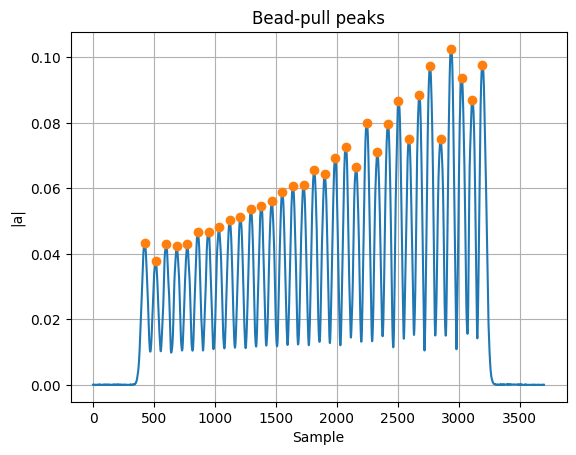

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.plot(np.abs(bdata.a))
plt.plot(bdata.locpk, np.abs(bdata.a[bdata.locpk]), "o")
plt.xlabel("Sample")
plt.ylabel("|a|")
plt.title("Bead-pull peaks")
plt.grid(True)
plt.show()